## Part 1

In [2]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt

import scipy.sparse as sp
import scipy.sparse.linalg as la

import numba as nb
from numba import cuda

import time

In [3]:
# Initialise plate.
# Choose odd N for definite centre term
N = 7

@nb.njit(parallel=True)
def dplate_maker(N):
    """
    Generate a csc data for a matrix representing the initial conditions of the plate.

    Parameters:
    N : int
        Number of grid points along one dimension of the square plate.

    Returns: tuple of np.ndarray
        Arrays representing the data, indices, and indptr for a sparse matrix.
    """
    # Define row, col, and data arrays for the sparse matrix
    data = np.zeros(N, dtype=np.float64)
    indptr = np.zeros(N+1, dtype=np.int64)
    indices = np.zeros(N, dtype=np.int64)

    # Set the left boundary (column index 0)
    for i in nb.prange(N):
        data[i] = 5.0  # Boundary condition value
        indices[i] = i  # Row indices for left boundary
        indptr[i+1] = N   # Cumulative column pointer

    return data, indices, indptr

def plate_maker(N):
    """
    Generate a flat matrix representing the initial conditions of the plate.

    Parameters:
    N : int
        Number of grid points along one dimension of the square plate.

    Returns: matrix
        flat matrix representation of the plate.
    """
    assert N % 2 == 1, "N must be odd to ensure a definite center term."
    assert N > 2, "N must be greater than 2 to define a valid grid."

    data, indices, indptr = dplate_maker(N)

    plate = sp.csc_matrix((data, indices, indptr), shape=(N, N))

    flat_plate = plate.reshape((N * N, 1))

    return flat_plate

flat_plate = plate_maker(N)


In [4]:
# Define time evolution matrix.
N = 3

@nb.njit
def boundary_conditions(data,indptr,row_indices):
    """
    Zero out matrix rows that correspond to boundary static heated elements.
    """
    for i in nb.prange(row_indices.size):
        row = row_indices[i]
        data[indptr[row]:indptr[row + 1]] = 0

    return data

def dt_matrix(N):
    """
    Generate the sparse matrix A for the 2D heat equation using a five-point stencil.
    The stencil computes:

    v_{rc} = (u_{r,c-1} + u_{r-1,c} - 4u_{r,c} + u_{r,c+1} + u_{r+1,c}) / h^2

    Boundary conditions are accounted for by zeroing out rows corresponding to
    static heated elements, and zeroing out u_{r,c+1} for the right boundary.

    Parameters:
    N : int
        Number of grid points along one dimension of the square plate.

    Returns:
    scipy.sparse.csr_matrix
        The sparse matrix A in CSR format.
    """
    assert N % 2 == 1, "N must be odd to ensure a definite center term."
    assert N > 2, "N must be greater than 2 to define a valid grid."

    h = 2 / (N-1)  # Spatial step size

    diagonals = np.array([1,1, -4, 1,1])
    offsets = np.array([-N,-1, 0, 1,N])

    A = sp.diags(diagonals, offsets, shape=(N**2, N**2), format="csr", dtype=np.float64)
    A.data /= h**2

    # Compute boundary row indices
    LHS_col_indices = np.arange(0, N**2, N)
    RHS_col_indices = np.arange(N - 1, N**2, N)
    Top_row_indices = np.arange(N)
    Bottom_row_indices = np.arange(N**2 - N, N**2)
    row_indices = np.unique(np.concatenate((LHS_col_indices, RHS_col_indices, Top_row_indices, Bottom_row_indices)))

    A.data = boundary_conditions(A.data, A.indptr, row_indices)

    A.eliminate_zeros()

    return(A)

A = dt_matrix(N)
print(A.toarray())

[[ 0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  1.  0.  1. -4.  1.  0.  1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.]]


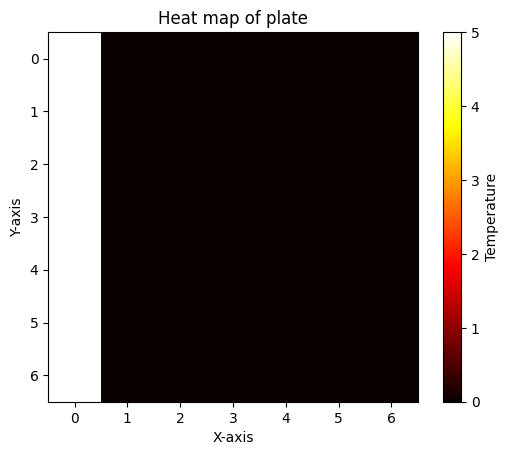

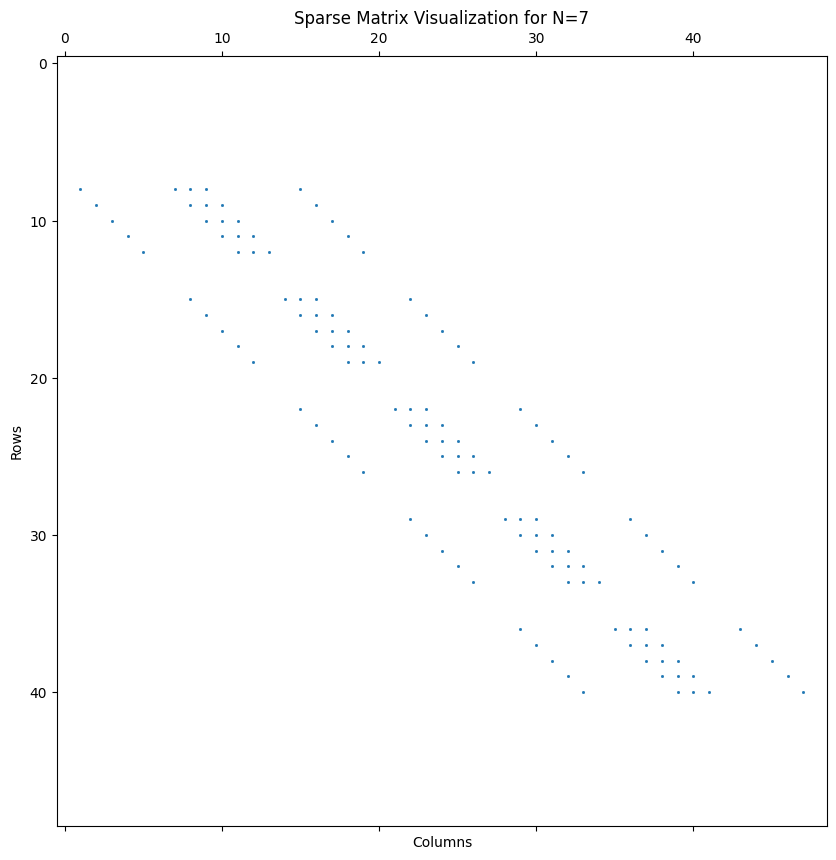

In [7]:
# Plot heat maps of A and flat_plate
N = 7

def plot_plate(matrix, N):
    """
    Plot the 2D map of the initial conditions.

    Parameters:
    csc_matrix : scipy.sparse.csc_matrix
        The CSC matrix representing the initial conditions.
    N : int
        The dimension of the square plate.
    """
    dense_matrix = matrix.toarray().reshape((N, N))
    plt.imshow(dense_matrix, cmap='hot', interpolation='nearest')
    plt.colorbar(label='Temperature')
    plt.title('Heat map of plate')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.show()

def plot_csr_matrix(csr_matrix, title="Sparse Matrix Visualization"):
    """
    Plot the structure of a sparse matrix in CSR format.

    Parameters:
    csr_matrix : scipy.sparse.csr_matrix
        The sparse matrix to be visualized.

    title : str, optional
        Title for the plot.
    """
    if not sp.isspmatrix_csr(csr_matrix):
        raise ValueError("Input must be a CSR sparse matrix.")

    plt.figure(figsize=(10, 10))
    plt.spy(csr_matrix, markersize=1, precision=0.1)
    plt.title(title)
    plt.xlabel("Columns")
    plt.ylabel("Rows")
    plt.show()

A = dt_matrix(N)
flat_plate = plate_maker(N)

# Plot the initial conditions
plot_plate(flat_plate, N)
plot_csr_matrix(A, title=f"Sparse Matrix Visualization for N={N}")

In [25]:
 #Iterate through time functions

def time_evolution_cpu(N, dt, starting_plate=None, t_start=0, print_interval=100):
    """
    Simulate the time evolution of the 2D heat equation until the center reaches u >= 1.

    Parameters:
    N : Number of grid points along one dimension of the square plate (must be odd).
    dt : Time step size.
    t_start : Initial time (default: 0).
    starting_plate : Optional initial plate state (default: None).
    print_interval : Interval for printing progress to the console (default: every 100 iterations).

    Returns:
    t: float
        Time at which the center point reaches u >= 1.
    """
    assert N % 2 == 1, "N must be odd to ensure a definite center term."
    assert N > 2, "N must be greater than 2 to define a valid grid."

    h = 2 / (N-1)  # Spatial step size
    assert dt < h**2 / 4, "dt is too large for explicit Euler stability."

    t = t_start

    # Initialize the flat plate
    if starting_plate is None:
        flat_plate = plate_maker(N).toarray()
    else:
        assert starting_plate.shape == (N**2,), "Starting plate must have shape (N^2,)"
        flat_plate = starting_plate

    # Extract CSR matrix data
    A = dt_matrix(N)  # Get the sparse matrix in CSR format

    centre_index = (N//2)*N + (N//2)

    u_centre = flat_plate[centre_index,0]
    iteration = 0
    while flat_plate[centre_index,0] < 1:
        # Compute time derivative using sparse_matvec
        udot = A @ flat_plate

        # Update the current state
        flat_plate += dt * udot

        # Increment time
        t += dt

        # Store value for centre u
        #u_centre.append(flat_plate[centre_index,0])

    # Final progress update
    print(f"\nCenter point reached u >= 1 at t = {t}")

    return t,flat_plate,u_centre


In [27]:
# Run function
N = 201
dt = 1e-5

start_time = time.time()
t, flat_plate, u_centre_t = time_evolution_cpu(N, 1e-5, print_interval = 20)
end_time = time.time()

print(f"Time taken: {end_time - start_time} seconds")


Center point reached u >= 1 at t = 0.42401000000028327
Time taken: 22.408612489700317 seconds


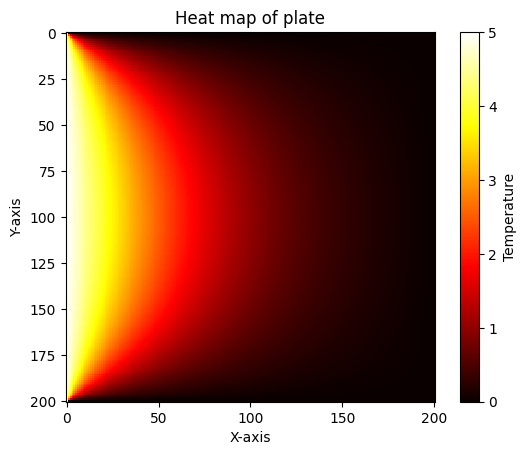

[0.979351128866754, 0.9793634338083981, 0.9793757381472098, 0.9793880418832182, 0.9794003450164521, 0.9794126475469407, 0.9794249494747128, 0.9794372507997975, 0.9794495515222237, 0.9794618516420202, 0.9794741511592162, 0.9794864500738407, 0.9794987483859225, 0.9795110460954907, 0.9795233432025741, 0.9795356397072017, 0.9795479356094026, 0.9795602309092056, 0.9795725256066398, 0.979584819701734]
42400.99999999999


In [ ]:
# Plot plate
#print(flat_plate[(N**2+1)//2,0])
plot_plate(flat_plate, N)

print(u_centre_t[-20:])

t_ideal = 0.424011387033
print(0.42401/1e-5)